## Light curves for some prominent variable stars

### Gamma Cas

Use this site to get csv - https://britastro.org/vss/

Loaded style tokens from: /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/style/hud_style_tokens.py
Loaded config for: data/GAMMA_CAS.csv
Date range: ('2020-06-01', '2024-12-31')
Y limits: auto
Output folder: /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Papers/shared/animations/light_curves
Columns in the CSV file:
['Object', 'Julian Date', 'UT', 'Magnitude Qualifier', 'Magnitude', 'Magnitude Error', 'Observer Name', 'Method', 'Equipment', 'Filter', 'Chart / Sequence', 'Visual Estimates', 'CCD Measurement Data: Measurement Type;Star Type;Star Id;Measured Mag;Measured Error;Reference Mag;Reference Error', 'Observation_Id']

First 5 rows:
      Object  Julian Date                    UT Magnitude Qualifier  \
0  GAMMA CAS  2460783.417  17 Apr 2025 22:00:00               Equal   
1  GAMMA CAS  2460774.396   8 Apr 2025 21:30:00               Equal   
2  GAMMA CAS  2460769.433   3 Apr 2025 22:23:00               Equal   
3  GAMMA CAS  2460767.396   1 Apr 2025 21:30:00   

/Users/mloktionov/anaconda3/envs/astro-ai/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 48 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


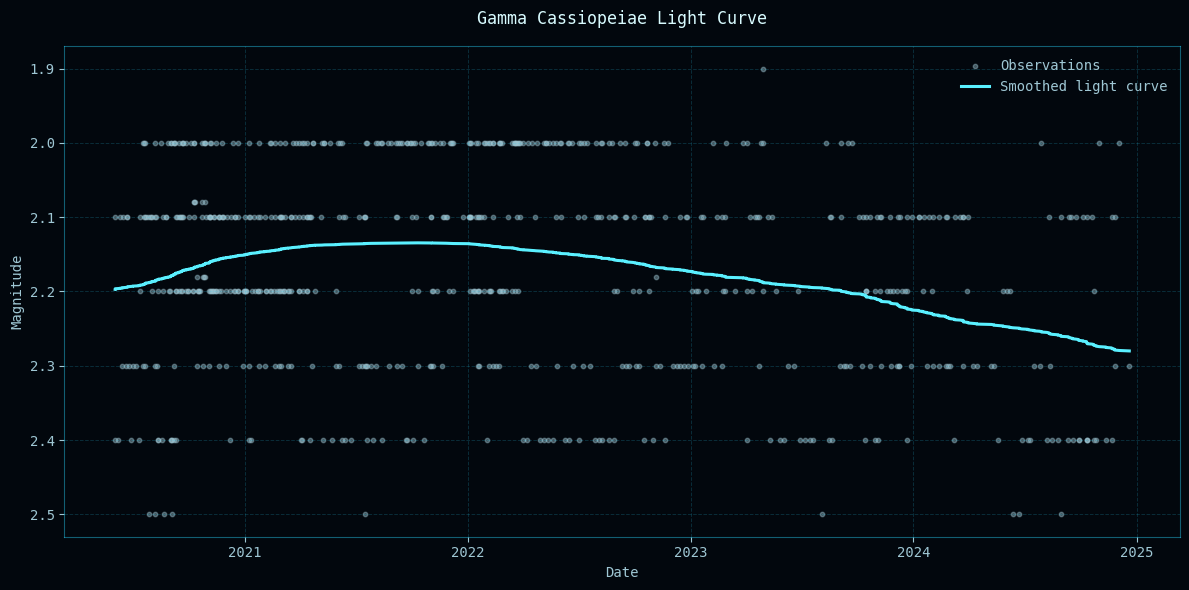

Saved: animations/light_curves/gamma_cas_light_curve.png
Saved: animations/light_curves/gamma_cas_light_curve.gif


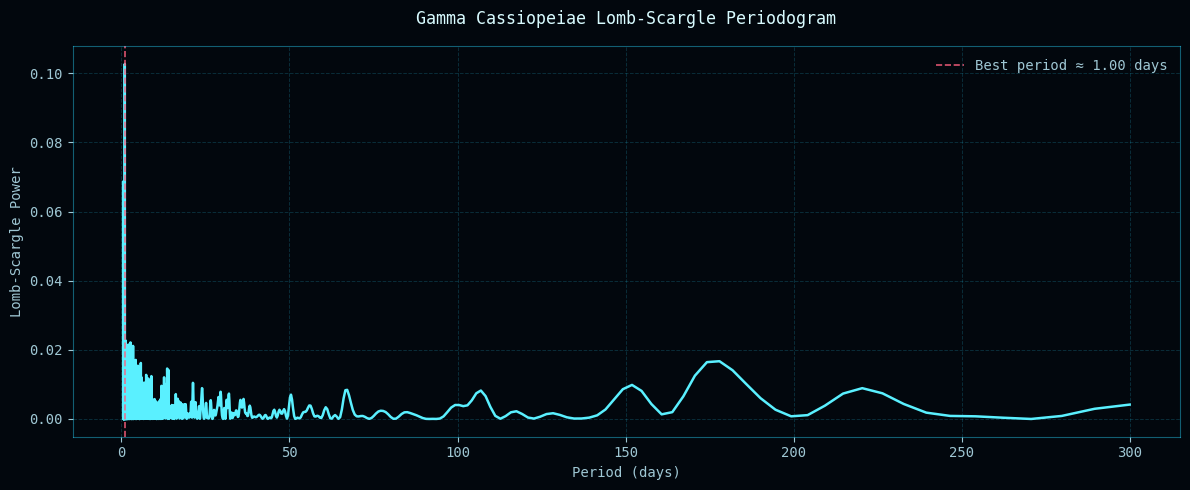

Saved: animations/light_curves/gamma_cas_lomb_scargle.png
Estimated period: 0.9999 days
Saved: animations/light_curves/gamma_cas_lomb_scargle.gif


In [6]:
from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.interpolate import UnivariateSpline
from astropy.time import Time
from astropy.timeseries import LombScargle

# =========================================================
# CONFIG
# =========================================================

DATA_DIR = Path("data")
OUT_DIR = Path("animations/light_curves")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILE_NAME = "GAMMA_CAS.csv"
FILE_PATH = DATA_DIR / FILE_NAME

OBJECT_NAME = "Gamma Cassiopeiae"
X_RANGE = ("2020-06-01", "2024-12-31")
Y_LIM = None  # example: (2.4, 2.0). Magnitudes: lower is brighter.

MIN_PERIOD = 0.5
MAX_PERIOD = 300

THEME = "dark"  # "dark" or "light"
DPI = 160

LIGHT_CURVE_OUT = OUT_DIR / "gamma_cas_light_curve.png"
PERIODOGRAM_OUT = OUT_DIR / "gamma_cas_lomb_scargle.png"

from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter

# =========================================================
# ANIMATION CONFIG
# =========================================================

OUTPUT_FORMAT = "gif"   # "gif" or "mp4"
FPS = 24
FRAMES = 160

LC_ANIM_OUT = OUT_DIR / f"gamma_cas_light_curve.{OUTPUT_FORMAT}"
LS_ANIM_OUT = OUT_DIR / f"gamma_cas_lomb_scargle.{OUTPUT_FORMAT}"


def save_animation(anim, out_file: Path):
    out_file.parent.mkdir(parents=True, exist_ok=True)

    if OUTPUT_FORMAT.lower() == "gif":
        writer = PillowWriter(fps=FPS)
        anim.save(out_file, writer=writer, dpi=DPI)

    elif OUTPUT_FORMAT.lower() == "mp4":
        writer = FFMpegWriter(
            fps=FPS,
            metadata=dict(artist="Stellar Attractor"),
            bitrate=2400,
        )
        anim.save(out_file, writer=writer, dpi=DPI)

    else:
        raise ValueError("OUTPUT_FORMAT must be 'gif' or 'mp4'")

    print(f"Saved: {out_file}")


# =========================================================
# LOAD STELLAR ATTRACTOR TOKENS
# =========================================================

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for p in [start, *start.parents]:
        if (p / "style" / "hud_style_tokens.py").exists():
            return p

    return Path.cwd()


def load_tokens():
    path = find_project_root() / "style" / "hud_style_tokens.py"

    if not path.exists():
        print("Style tokens not found, using fallback palette.")
        return None

    spec = importlib.util.spec_from_file_location("hud_style_tokens", path)
    tokens = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(tokens)

    print(f"Loaded style tokens from: {path}")
    return tokens


def mpl_color(value):
    if isinstance(value, tuple) and len(value) == 3:
        return tuple(v / 255 for v in value)
    return value


tokens = load_tokens()

if THEME == "dark":
    BG = mpl_color(getattr(tokens, "SA_COLORS_BG", (2, 7, 13))) if tokens else "#02070d"
    TEXT = mpl_color(getattr(tokens, "SA_COLORS_TEXT_MAIN", (216, 251, 255))) if tokens else "#d8fbff"
    TEXT_DIM = mpl_color(getattr(tokens, "SA_COLORS_TEXT_DIM", (159, 199, 212))) if tokens else "#9fc7d4"
    GRID = mpl_color(getattr(tokens, "SA_CHART_GRID_COLOR", (42, 215, 255))) if tokens else "#2ad7ff"
    LINE = mpl_color(getattr(tokens, "SA_CHART_LINE_COLOR", (90, 240, 255))) if tokens else "#5af0ff"
    MARKER = mpl_color(getattr(tokens, "SA_CHART_MARKER_COLOR", (143, 252, 255))) if tokens else "#8ffcff"
    ALERT = mpl_color(getattr(tokens, "SA_COLORS_RED", (255, 95, 127))) if tokens else "#ff5f7f"
else:
    BG = "#f7fbff"
    TEXT = "#071a24"
    TEXT_DIM = "#33515c"
    GRID = "#8aa9b3"
    LINE = "#007a9a"
    MARKER = "#0a88a8"
    ALERT = "#b00030"

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "DejaVu Sans Mono",
    "mathtext.fontset": "dejavusans",
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": TEXT,
    "axes.labelcolor": TEXT_DIM,
    "xtick.color": TEXT_DIM,
    "ytick.color": TEXT_DIM,
    "axes.edgecolor": GRID,
})

print(f"Loaded config for: {FILE_PATH}")
print(f"Date range: {X_RANGE}")
print(f"Y limits: {Y_LIM if Y_LIM else 'auto'}")
print(f"Output folder: {OUT_DIR.resolve()}")

# =========================================================
# LOAD / CLEAN DATA
# =========================================================

df_raw = pd.read_csv(FILE_PATH)

print("Columns in the CSV file:")
print(df_raw.columns.tolist())

print("\nFirst 5 rows:")
print(df_raw.head())

print(f"\nNumber of records: {len(df_raw)}")

required_columns = ["Julian Date", "Magnitude"]
missing = [col for col in required_columns if col not in df_raw.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df_raw[required_columns].dropna()
df = df[df["Magnitude"].between(0, 10)]

df["Date"] = Time(
    df["Julian Date"].values,
    format="jd"
).to_datetime()

df = df[
    (df["Date"] >= pd.Timestamp(X_RANGE[0])) &
    (df["Date"] <= pd.Timestamp(X_RANGE[1]))
]

df = df.sort_values("Date").reset_index(drop=True)

if len(df) < 5:
    raise RuntimeError("Not enough data points after filtering.")

dates = df["Date"].values
mags = df["Magnitude"].values


print(f"\nFiltered records: {len(df)}")
print(f"Date range in data: {df['Date'].min()} — {df['Date'].max()}")

# =========================================================
# SMOOTH LIGHT CURVE
# =========================================================

x_numeric = np.arange(len(dates))

spline_s = max(0.5, len(df) * 0.03)

spline = UnivariateSpline(
    x_numeric,
    mags,
    s=spline_s
)

x_smooth = np.linspace(
    0,
    len(dates) - 1,
    1000
)

mag_smooth = spline(x_smooth)
smooth_idx = np.clip(
    x_smooth.astype(int),
    0,
    len(dates) - 1
)
dates_num = mdates.date2num(pd.to_datetime(dates))
smooth_dates_num = dates_num[smooth_idx]

# =========================================================
# LIGHT CURVE PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    dates,
    mags,
    color=TEXT_DIM,
    s=10,
    alpha=0.42,
    label="Observations"
)

ax.plot(
    dates[smooth_idx],
    mag_smooth,
    color=LINE,
    linewidth=2.2,
    label="Smoothed light curve"
)

ax.invert_yaxis()

if Y_LIM is not None:
    ax.set_ylim(*Y_LIM)

ax.set_xlabel("Date")
ax.set_ylabel("Magnitude")
ax.set_title(f"{OBJECT_NAME} Light Curve", color=TEXT, pad=16)

ax.grid(
    True,
    color=GRID,
    linestyle="--",
    linewidth=0.7,
    alpha=0.18
)

legend = ax.legend(
    frameon=False,
    labelcolor=TEXT_DIM
)

for spine in ax.spines.values():
    spine.set_color(GRID)
    spine.set_alpha(0.42)

ax.tick_params(colors=TEXT_DIM)

fig.tight_layout()
fig.savefig(LIGHT_CURVE_OUT, dpi=DPI)
plt.show()

print(f"Saved: {LIGHT_CURVE_OUT}")

# =========================================================
# ANIMATED LIGHT CURVE — LEFT TO RIGHT
# =========================================================

fig, ax = plt.subplots(figsize=(12, 6))

ax.set_facecolor(BG)
ax.set_xlabel("Date")
ax.set_ylabel("Magnitude")
ax.set_title(f"{OBJECT_NAME} Light Curve", color=TEXT, pad=16)

ax.invert_yaxis()

if Y_LIM is not None:
    ax.set_ylim(*Y_LIM)
else:
    y_min = np.nanmin(mags)
    y_max = np.nanmax(mags)
    margin = (y_max - y_min) * 0.08
    ax.set_ylim(y_max + margin, y_min - margin)

ax.set_xlim(dates[0], dates[-1])

ax.grid(
    True,
    color=GRID,
    linestyle="--",
    linewidth=0.7,
    alpha=0.18
)

for spine in ax.spines.values():
    spine.set_color(GRID)
    spine.set_alpha(0.42)

ax.tick_params(colors=TEXT_DIM)

scatter = ax.scatter(
    [],
    [],
    color=TEXT_DIM,
    s=10,
    alpha=0.38,
    label="Observations"
)

curve_line, = ax.plot(
    [],
    [],
    color=LINE,
    linewidth=2.2,
    label="Smoothed light curve"
)

legend = ax.legend(frameon=False, labelcolor=TEXT_DIM)

for text in legend.get_texts():
    text.set_color(TEXT_DIM)

def init_light_curve():
    scatter.set_offsets(np.empty((0, 2)))
    curve_line.set_data([], [])
    return scatter, curve_line


def update_light_curve(frame):
    progress = frame / max(1, FRAMES - 1)

    n_obs = max(1, int(progress * len(dates_num)))
    n_smooth = max(2, int(progress * len(x_smooth)))

    scatter.set_offsets(
        np.column_stack([
            dates_num[:n_obs],
            mags[:n_obs]
        ])
    )

    curve_line.set_data(
        smooth_dates_num[:n_smooth],
        mag_smooth[:n_smooth]
    )

    return scatter, curve_line


light_curve_anim = FuncAnimation(
    fig,
    update_light_curve,
    frames=FRAMES,
    init_func=init_light_curve,
    interval=1000 / FPS,
    blit=False,
)

fig.tight_layout()
save_animation(light_curve_anim, LC_ANIM_OUT)
plt.close(fig)


# =========================================================
# LOMB-SCARGLE
# =========================================================

time = df["Julian Date"].values
mag = df["Magnitude"].values

mask = np.isfinite(time) & np.isfinite(mag)
time = time[mask]
mag = mag[mask]

mag_centered = mag - np.mean(mag)

frequency, power = LombScargle(
    time,
    mag_centered
).autopower(
    minimum_frequency=1 / MAX_PERIOD,
    maximum_frequency=1 / MIN_PERIOD
)

period = 1 / frequency
best_period = period[np.argmax(power)]
order = np.argsort(period)
period = period[order]
power = power[order]

# =========================================================
# PERIODOGRAM PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    period,
    power,
    color=LINE,
    linewidth=1.8
)

ax.axvline(
    best_period,
    color=ALERT,
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    label=f"Best period ≈ {best_period:.2f} days"
)

ax.set_xlabel("Period (days)")
ax.set_ylabel("Lomb-Scargle Power")
ax.set_title(f"{OBJECT_NAME} Lomb-Scargle Periodogram", color=TEXT, pad=16)

ax.grid(
    True,
    color=GRID,
    linestyle="--",
    linewidth=0.7,
    alpha=0.18
)

legend = ax.legend(
    frameon=False,
    labelcolor=TEXT_DIM
)

for spine in ax.spines.values():
    spine.set_color(GRID)
    spine.set_alpha(0.42)

ax.tick_params(colors=TEXT_DIM)

fig.tight_layout()
fig.savefig(PERIODOGRAM_OUT, dpi=DPI)
plt.show()

print(f"Saved: {PERIODOGRAM_OUT}")
print(f"Estimated period: {best_period:.4f} days")

# =========================================================
# ANIMATED LOMB-SCARGLE — LEFT TO RIGHT
# =========================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.set_facecolor(BG)
ax.set_xlabel("Period (days)")
ax.set_ylabel("Lomb-Scargle Power")
ax.set_title(f"{OBJECT_NAME} Lomb-Scargle Periodogram", color=TEXT, pad=16)

ax.set_xlim(np.nanmin(period), np.nanmax(period))
ax.set_ylim(0, np.nanmax(power) * 1.12)

ax.grid(
    True,
    color=GRID,
    linestyle="--",
    linewidth=0.7,
    alpha=0.18
)

for spine in ax.spines.values():
    spine.set_color(GRID)
    spine.set_alpha(0.42)

ax.tick_params(colors=TEXT_DIM)

period_line, = ax.plot(
    [],
    [],
    color=LINE,
    linewidth=1.8
)

best_line = ax.axvline(
    best_period,
    color=ALERT,
    linestyle="--",
    linewidth=1.2,
    alpha=0.0,
)

best_label = ax.text(
    best_period,
    np.nanmax(power) * 1.04,
    f"{best_period:.2f} d",
    color=ALERT,
    ha="center",
    va="bottom",
    fontsize=9,
    alpha=0.0,
)

def init_lomb_scargle():
    period_line.set_data([], [])
    best_line.set_alpha(0.0)
    best_label.set_alpha(0.0)
    return period_line, best_line, best_label


def update_lomb_scargle(frame):
    progress = frame / max(1, FRAMES - 1)
    n = max(2, int(progress * len(period)))

    period_line.set_data(period[:n], power[:n])

    if progress > 0.92:
        a = min(1.0, (progress - 0.92) / 0.08)
        best_line.set_alpha(0.85 * a)
        best_label.set_alpha(a)

    return period_line, best_line, best_label


lomb_anim = FuncAnimation(
    fig,
    update_lomb_scargle,
    frames=FRAMES,
    init_func=init_lomb_scargle,
    interval=1000 / FPS,
    blit=False,
)

fig.tight_layout()
save_animation(lomb_anim, LS_ANIM_OUT)
plt.close(fig)